# New Zealand Health Statistics

This notebook demonstrates how to access health statistics for **New Zealand / Aotearoa** using the `nz_health` accessor.

**Data Sources:**
- **Stats NZ** — Mortality, life tables, births and deaths ([stats.govt.nz](https://www.stats.govt.nz/topics/health/))
- **Health New Zealand | Te Whatu Ora** — Hospital events, immunisation coverage ([tewhatuora.govt.nz](https://www.tewhatuora.govt.nz/for-health-professionals/data-and-statistics/))

**Coverage:**
- **Geographic:** New Zealand (single country)
- **Temporal:** Annual time series
- **Topics:** Mortality, hospital events, life expectancy, childhood immunisation

> **Note:** Live data files on the Stats NZ / Health NZ portals are released as periodically-updated Excel files.  
> This accessor provides representative **sample data** (`sample=True`) so analyses work reproducibly without scraping changing URLs.

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 09:12


## 2. Initialize the Accessor

You can instantiate via the unified registry with `get_source("nz_health")` or directly.

In [2]:
from epidatasets.sources.nz_health import NZHealthAccessor

nz = NZHealthAccessor()

print(f"Source      : {nz.source_name}")
print(f"Description : {nz.source_description}")
print(f"Portal      : {nz.source_url}")

Source      : nz_health
Description : New Zealand health statistics from Stats NZ and Health New Zealand | Te Whatu Ora
Portal      : https://www.stats.govt.nz/topics/health/


In [3]:
# Country coverage
countries = nz.list_countries()
print(countries.to_string(index=False))

country_code country_name
         NZL  New Zealand


## 3. Mortality Data

Annual mortality statistics from Stats NZ, broken down by age group and sex.

In [4]:
mortality = nz.get_mortality(sample=True)
print(f"Mortality data: {mortality.shape}")
display(mortality[['year', 'total_deaths', 'male_deaths', 'female_deaths', 'infant_deaths']])

Mortality data: (5, 11)


,year,total_deaths,male_deaths,female_deaths,infant_deaths
0,2019,34260,17130,17130,183
1,2020,32613,16307,16306,174
2,2021,34932,17466,17466,186
3,2022,38574,19287,19287,207
4,2023,37884,18942,18942,202


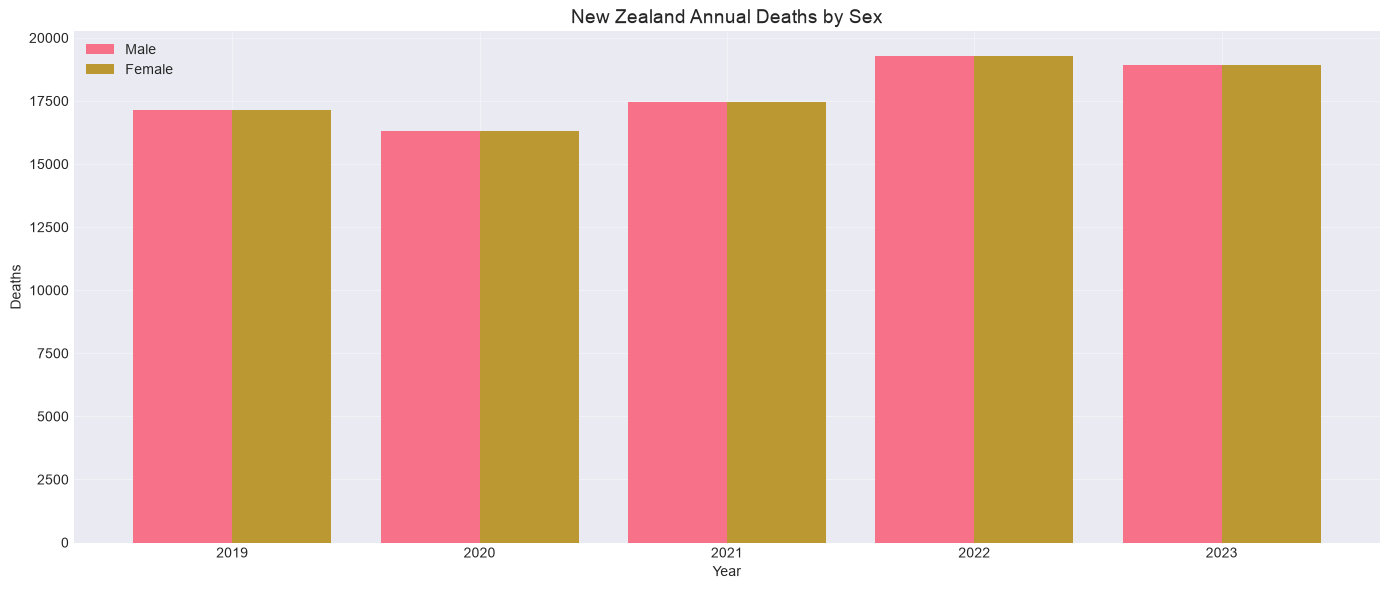

In [5]:
fig, ax = plt.subplots()
ax.bar(mortality['year'] - 0.2, mortality['male_deaths'], width=0.4, label='Male')
ax.bar(mortality['year'] + 0.2, mortality['female_deaths'], width=0.4, label='Female')
ax.set_title('New Zealand Annual Deaths by Sex', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Deaths')
ax.legend()
plt.tight_layout()
plt.show()

### Mortality by age group

The breakdown by age band highlights the concentration of deaths in older age groups.

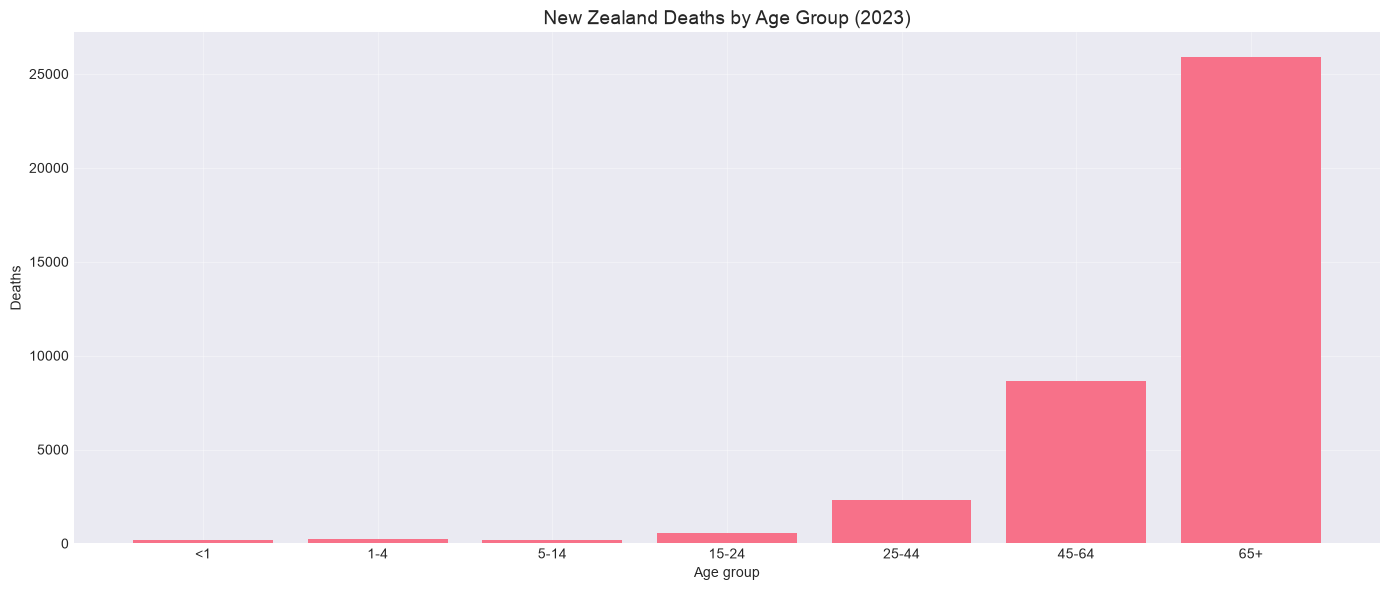

In [6]:
age_cols = [
    'infant_deaths', 'under_5_deaths', 'age_5_14_deaths',
    'age_15_24_deaths', 'age_25_44_deaths', 'age_45_64_deaths',
    'age_65_plus_deaths',
]
age_labels = ['<1', '1-4', '5-14', '15-24', '25-44', '45-64', '65+']

latest = mortality.iloc[-1]

fig, ax = plt.subplots()
ax.bar(age_labels, latest[age_cols].values)
ax.set_title(f'New Zealand Deaths by Age Group ({int(latest["year"])})', fontsize=14)
ax.set_xlabel('Age group')
ax.set_ylabel('Deaths')
plt.tight_layout()
plt.show()

## 4. Life Tables

Life expectancy at birth from Stats NZ, including healthy life expectancy estimates.

In [7]:
life = nz.get_life_tables(sample=True)
print(f"Life tables: {life.shape}")
display(life[['year', 'male_life_expectancy', 'female_life_expectancy', 'total_life_expectancy']])

Life tables: (5, 6)


,year,male_life_expectancy,female_life_expectancy,total_life_expectancy
0,2019,80.0,83.5,81.7
1,2020,80.2,83.7,81.9
2,2021,80.1,83.6,81.8
3,2022,80.3,83.8,82.0
4,2023,80.5,84.0,82.2


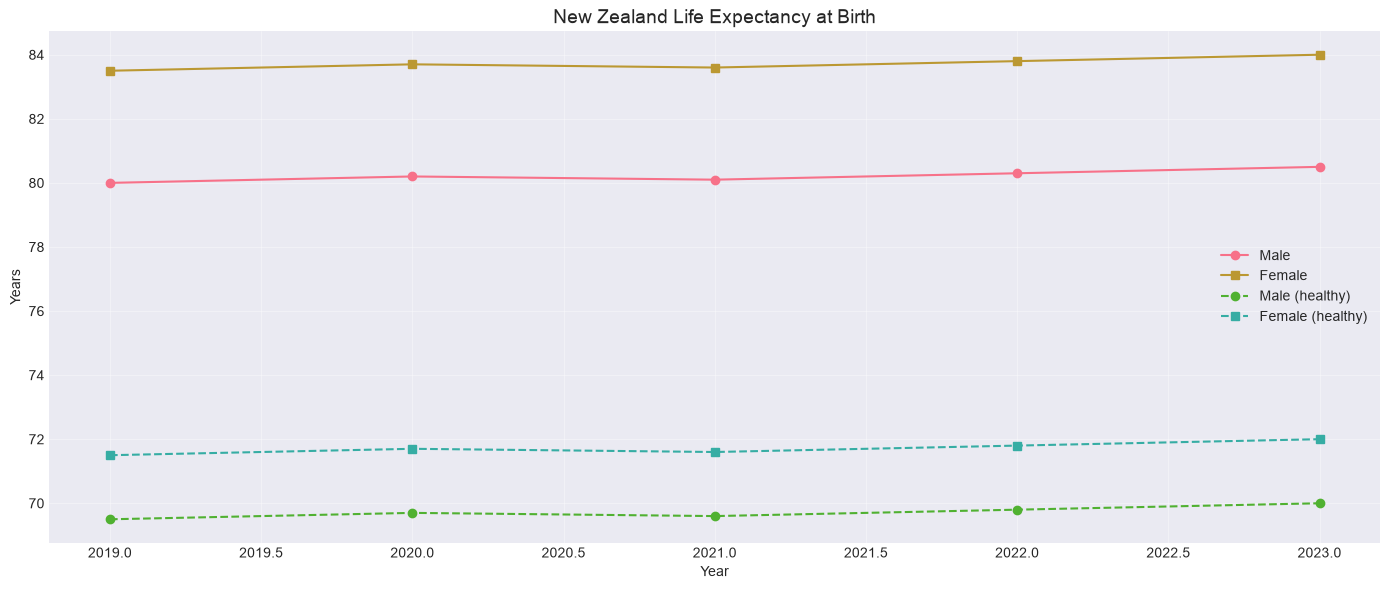

In [8]:
fig, ax = plt.subplots()
ax.plot(life['year'], life['male_life_expectancy'], marker='o', label='Male')
ax.plot(life['year'], life['female_life_expectancy'], marker='s', label='Female')
ax.plot(life['year'], life['male_healthy_life_expectancy'], marker='o',
        linestyle='--', label='Male (healthy)')
ax.plot(life['year'], life['female_healthy_life_expectancy'], marker='s',
        linestyle='--', label='Female (healthy)')
ax.set_title('New Zealand Life Expectancy at Birth', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Years')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Hospital Events

Hospital activity from Health New Zealand | Te Whatu Ora, including public/private discharges and emergency department visits.

In [9]:
hospitals = nz.get_hospital_events(sample=True)
print(f"Hospital events: {hospitals.shape}")
display(hospitals[['year', 'total_discharges', 'average_length_of_stay', 'emergency_department_visits']])

Hospital events: (5, 7)


,year,total_discharges,average_length_of_stay,emergency_department_visits
0,2019,1500000,4.5,800000
1,2020,1400000,4.3,750000
2,2021,1450000,4.4,780000
3,2022,1550000,4.6,820000
4,2023,1600000,4.7,850000


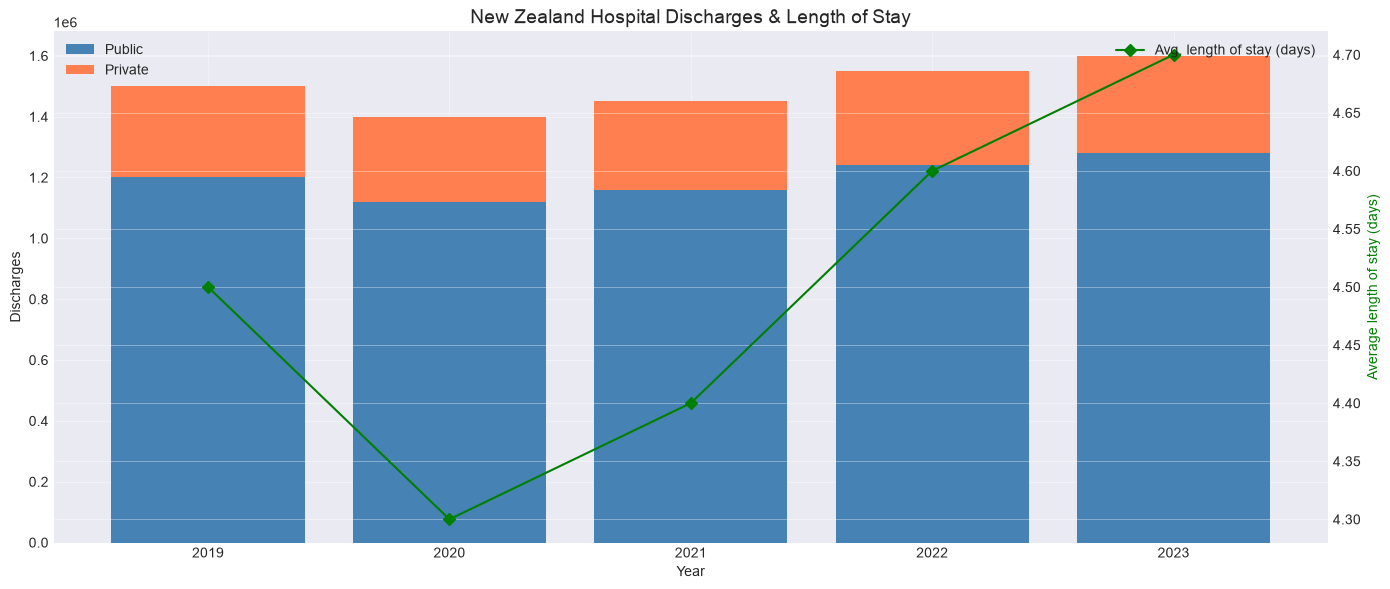

In [10]:
fig, ax1 = plt.subplots()
ax1.bar(hospitals['year'], hospitals['public_hospital_discharges'],
        label='Public', color='steelblue')
ax1.bar(hospitals['year'], hospitals['private_hospital_discharges'],
        bottom=hospitals['public_hospital_discharges'],
        label='Private', color='coral')
ax1.set_ylabel('Discharges')
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(hospitals['year'], hospitals['average_length_of_stay'],
         color='green', marker='D', label='Avg. length of stay (days)')
ax2.set_ylabel('Average length of stay (days)', color='green')

ax1.set_title('New Zealand Hospital Discharges & Length of Stay', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Childhood Immunisation Coverage

Immunisation coverage by vaccine, dose, and age milestone, compared against national targets.

In [11]:
imm = nz.get_immunisation_coverage()
print(f"Immunisation records: {len(imm)}")
display(imm[['vaccine', 'dose', 'age_group', 'coverage_2023', 'target']])

Immunisation records: 9


,vaccine,dose,age_group,coverage_2023,target
0,DTaP-IPV-HepB/Hib,1,6 weeks,96.0,95.0
1,DTaP-IPV-HepB/Hib,2,3 months,95.0,95.0
2,DTaP-IPV-HepB/Hib,3,5 months,94.0,95.0
3,MMR,1,12 months,93.0,95.0
4,MMR,2,15 months,92.0,95.0
5,MMR,3,4 years,91.0,95.0
6,HPV,1,Year 8,87.0,90.0
7,HPV,2,Year 8,86.0,90.0
8,HPV,3,Year 8,85.0,90.0


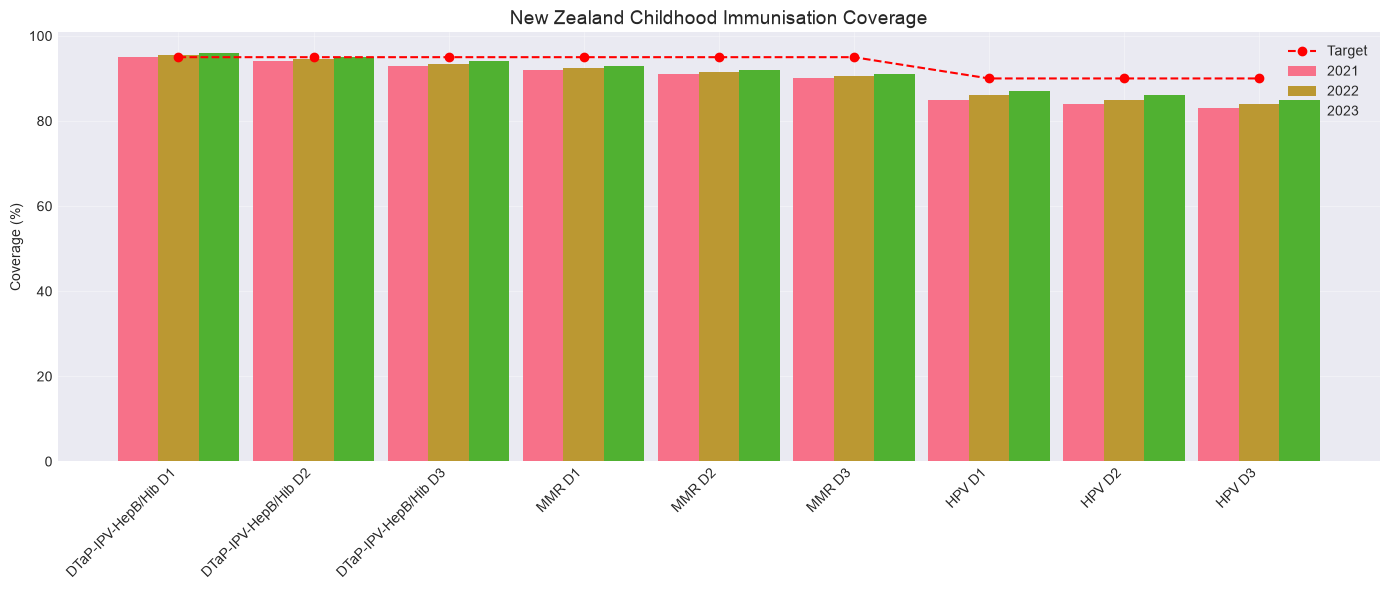

In [12]:
labels = imm['vaccine'] + ' D' + imm['dose'].astype(str)
x = range(len(imm))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - 0.3 for i in x], imm['coverage_2021'], width=0.3, label='2021')
ax.bar(x, imm['coverage_2022'], width=0.3, label='2022')
ax.bar([i + 0.3 for i in x], imm['coverage_2023'], width=0.3, label='2023')
ax.plot(x, imm['target'], color='red', linestyle='--', marker='o', label='Target')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('New Zealand Childhood Immunisation Coverage', fontsize=14)
ax.set_ylabel('Coverage (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary

| Method | Description |
|--------|-------------|
| `get_mortality(sample=True)` | Annual deaths by sex and age group |
| `get_hospital_events(sample=True)` | Hospital discharges, ED visits, length of stay |
| `get_life_tables(sample=True)` | Life expectancy at birth (total & healthy) |
| `get_immunisation_coverage()` | Childhood vaccine coverage vs. targets |
| `list_countries()` | Country coverage (New Zealand) |

Pass `sample=True` to use the built-in representative dataset; omit it to attempt a live fetch (the accessor logs the relevant Stats NZ / Health NZ portal URL to browse for the latest release).

**Related notebooks:**
- [WHO Global Health Data](02_who_global_health_data.ipynb) — cross-country life-expectancy comparisons.
- [Eurostat EU Health Data](07_Eurostat_EU_Health_Data.ipynb) — comparable European health statistics.